# **Redes Neuronales Cuánticas con Data Re-uploading**
## *Sebastián González Juárez*

**Estructura:**

<div style="text-align: center;">
Data Re-uploading QNN<br>
↓<br>
Entrenamiento en PyTorch + PennyLane<br>
↓<br>
Escalamiento 1Q → 2Q → 3Q<br>
↓<br>
Clasificación del problema del círculo<br>
↓<br>
Comparación de desempeño
</div>

# **0. Imports y configuración**

**Obs: pennylane y torch**

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Reproducibilidad y equipo:**

In [2]:
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", DISPOSITIVO)
print("PyTorch:", torch.__version__)
print("PennyLane:", qml.__version__)

Dispositivo: cuda
PyTorch: 2.5.1+cu121
PennyLane: 0.37.0


**Parámetros y estrcutura:**

In [3]:
# Dataset círculo
N_MUESTRAS = 1000          # puntos totales del dataset círculo

# División de datos
TEST_SIZE = 0.20
VAL_SIZE = 0.20

# Entrenamiento
BATCH_SIZE = 32          # de una vez preparo el formato para imagenes

# Arquitectura QNN
N_QUBITS_INICIAL = 1
N_QUBITS_MAX = 3           # Solo hare: 1q -> 2q -> 3q
N_CAPAS = 6                # Por ahora vere si esto es poco o mucho

# Optimización
LR_1Q = 0.05          # para primer q un LR más alto
LR_NQ = 0.005         # al escalar, bajamos LR

EPOCHS_1Q = 30
EPOCHS_NQ = 30

# Simulación cuántica
SHOTS = None               # simulación exacta
DIFF_METHOD = "backprop"   # Por ahora me quedo con backprop, luego puedo probar Parameter Shift o adjoint

**Registros en memoria:**

In [4]:
historial = {}
resultados = {}
parametros_entrenados = {}

# **1. Dataset círculo**

**Función para generar los datos del círculo:**

In [5]:
def generar_dataset_circulo(n_muestras=1000, radio=0.55, semilla=42):
    """
    Dataset binario en R².
        - Clase 1: Interior del círculo
        - Clase 0: Exterior del círculo
    """
    rng = np.random.default_rng(semilla)
    X = rng.uniform(low=-1.0, high=1.0, size=(n_muestras, 2))
    radios = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
    y = (radios <= radio).astype(np.float32)

    return X.astype(np.float32), y

**Generar datos:**

In [6]:
X, y = generar_dataset_circulo(n_muestras=N_MUESTRAS, radio=0.55, semilla=SEMILLA)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nDistribución de clases:")
print(np.unique(y, return_counts=True))

X shape: (1000, 2)
y shape: (1000,)

Distribución de clases:
(array([0., 1.], dtype=float32), array([766, 234], dtype=int64))


**Visualización:**

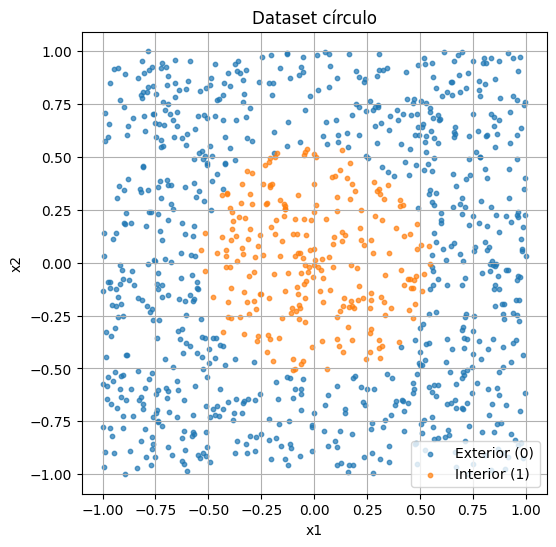

In [7]:
plt.figure(figsize=(6,6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=10, alpha=0.7, label="Exterior (0)")
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=10, alpha=0.7, label="Interior (1)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset círculo")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

**Padding para qml.Rot, agregamos un tercer parámetro pensando en futuro:**

In [8]:
def agregar_padding_rot(X):
    """
    Convierte: (x1, x2) en (x1, x2, 0)
    """
    columna_ceros = np.zeros((X.shape[0], 1),
        dtype=np.float32)
    X_rot = np.concatenate([X, columna_ceros],
        axis=1)

    return X_rot.astype(np.float32)

In [9]:
X_rot = agregar_padding_rot(X)

print("Shape original:", X.shape)
print("Shape para qml.Rot:", X_rot.shape)
print("\nEjemplo:")
print(X_rot[0])

Shape original: (1000, 2)
Shape para qml.Rot: (1000, 3)

Ejemplo:
[ 0.5479121  -0.12224312  0.        ]


**División Train / Validation / Test:**

In [10]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X_rot, y, test_size=TEST_SIZE, random_state=SEMILLA, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=VAL_SIZE, random_state=SEMILLA, stratify=y_train_val)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (640, 3)
Val: (160, 3)
Test: (200, 3)


**Conversión a tensores:**

In [11]:
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DISPOSITIVO)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DISPOSITIVO)

X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DISPOSITIVO)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DISPOSITIVO)

X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DISPOSITIVO)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=DISPOSITIVO)

**Verificación de dimensiones:**

In [12]:
print("X_train_t:", X_train_t.shape)
print("y_train_t:", y_train_t.shape)

print("X_val_t:", X_val_t.shape)
print("y_val_t:", y_val_t.shape)

print("X_test_t:", X_test_t.shape)
print("y_test_t:", y_test_t.shape)

X_train_t: torch.Size([640, 3])
y_train_t: torch.Size([640])
X_val_t: torch.Size([160, 3])
y_val_t: torch.Size([160])
X_test_t: torch.Size([200, 3])
y_test_t: torch.Size([200])


**DataLoaders:**

In [13]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

**Revisamos:**

In [14]:
print("Número de batches train:", len(train_loader))
print("Número de batches val:", len(val_loader))
print("Número de batches test:", len(test_loader))

print("\nEjemplo de entrada para qml.Rot:")
print(X_train_t[0])

Número de batches train: 20
Número de batches val: 5
Número de batches test: 7

Ejemplo de entrada para qml.Rot:
tensor([-0.8834, -0.4372,  0.0000], device='cuda:0')


# **2. Circuito QNN general n-qubits (Data Re-uploding)**

    Rot(x) → datos fijos
    Rot(theta) → parámetros entrenables
    CRot(phi) → acoplamiento entrenable entre qubits

**Fromación del circuito general**

En la sig celda defino el circuito QNN para cualquier número de qubits.

    i. e. La misma función servirá para 1q, 2q y 3q.


Circuito QNN de data re-uploading, para cada capa l:

        1. Se codifican los datos:
              qml.Rot(*x, wires=q)

        2. Se aplican parámetros entrenables:
              qml.Rot(*theta[l, q], wires=q)

        3. Si hay más de un qubit, se aplican acoplamientos:
              qml.CRot(*phi[l, q], wires=[q+1, q])

In [15]:
def circuito_qnn(
    x,               # x: Tensor de entrada con forma (3,). // Para el círculo usamos x = (x1, x2, 0).
    theta,           # theta: Parámetros locales entrenables. // Forma esperada: (n_capas, n_qubits, 3).
    phi,             # phi: Parámetros entrenables de compuertas controladas. // Forma esperada: (n_capas, n_qubits - 1, 3).
                     # Para 1 qubit no se usa.
    n_qubits,        # n_qubits: Número de qubits del circuito.
    n_capas          # n_capas: Número de capas de re-uploading.
):

    for l in range(n_capas):

        for q in range(n_qubits):

            # U(x): re-upload de datos
            qml.Rot(x[0], x[1], x[2], wires=q)

            # U(theta): rotación entrenable
            qml.Rot(theta[l, q, 0], theta[l, q, 1], theta[l, q, 2], wires=q)

        # Bloque de acoplamiento entre qubits vecinos.
        if n_qubits > 1:
            for q in range(n_qubits - 1):
                # CRot con control en q+1 y target en q.
                qml.CRot(phi[l, q, 0], phi[l, q, 1], phi[l, q, 2], wires=[q + 1, q])

**Construcción del QNode clasificador:**

Salida con:

    expval(PauliZ(0)): Valor esperado del operador Z en el primer qubit t. q. pertenece al intervalo [-1, 1].

In [16]:
def construir_qnode_clasificador(n_qubits, n_capas):
    dev = qml.device("default.qubit.torch", wires=n_qubits, shots=SHOTS, torch_device="cuda:0")

    @qml.qnode(dev, interface="torch", diff_method=DIFF_METHOD)
    def qnode(x, theta, phi):
        circuito_qnn(x=x, theta=theta, phi=phi, n_qubits=n_qubits, n_capas=n_capas)
        return qml.expval(qml.PauliZ(wires=0))
    return qnode

**Pruebo el circuito con 1 qubit para ver dim.**

In [17]:
n_qubits_prueba = 1

qnode_prueba_1q = construir_qnode_clasificador(n_qubits=n_qubits_prueba, n_capas=N_CAPAS)
x_prueba = X_train_t[0]
theta_prueba_1q = torch.randn(N_CAPAS, n_qubits_prueba, 3, dtype=torch.float32, device=DISPOSITIVO, requires_grad=True)
phi_prueba_1q = torch.zeros(N_CAPAS, 1, 3, dtype=torch.float32, device=DISPOSITIVO, requires_grad=True)
salida_prueba_1q = qnode_prueba_1q(x_prueba, theta_prueba_1q, phi_prueba_1q)

print("=== Prueba 1 qubit ===")
print("x_prueba:", x_prueba.shape)
print("theta:", theta_prueba_1q.shape)
print("phi:", phi_prueba_1q.shape)
print("Salida <Z0>:", salida_prueba_1q)

=== Prueba 1 qubit ===
x_prueba: torch.Size([3])
theta: torch.Size([6, 1, 3])
phi: torch.Size([6, 1, 3])
Salida <Z0>: tensor(0.8424, device='cuda:0', dtype=torch.float64, grad_fn=<ViewBackward0>)


(<Figure size 1500x200 with 1 Axes>, <Axes: >)


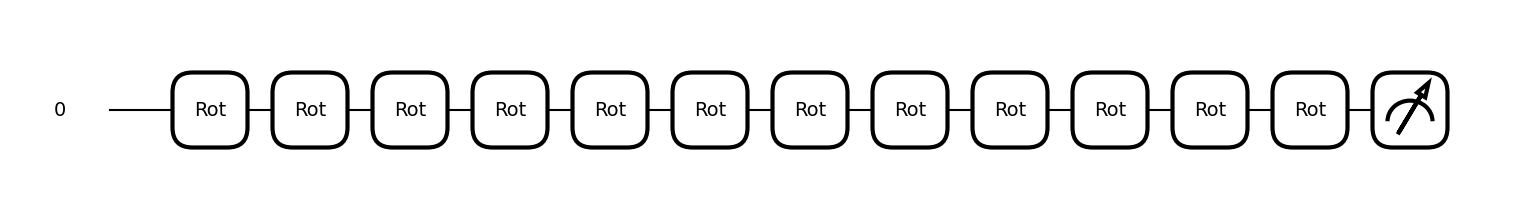

In [18]:
print(qml.draw_mpl(qnode_prueba_1q)(x_prueba, theta_prueba_1q, phi_prueba_1q))

**Pruebo el circuito con 2 qubit para ver dim.**

In [19]:
n_qubits_prueba = 2

qnode_prueba_2q = construir_qnode_clasificador(n_qubits=n_qubits_prueba, n_capas=N_CAPAS)
theta_prueba_2q = torch.randn(N_CAPAS, n_qubits_prueba, 3, dtype=torch.float32, device=DISPOSITIVO, requires_grad=True)
phi_prueba_2q = torch.zeros(N_CAPAS, n_qubits_prueba - 1, 3, dtype=torch.float32, device=DISPOSITIVO, requires_grad=True)
salida_prueba_2q = qnode_prueba_2q(x_prueba, theta_prueba_2q, phi_prueba_2q)

print("=== Prueba 2 qubits ===")
print("x_prueba:", x_prueba.shape)
print("theta:", theta_prueba_2q.shape)
print("phi:", phi_prueba_2q.shape)
print("Salida <Z0>:", salida_prueba_2q)

=== Prueba 2 qubits ===
x_prueba: torch.Size([3])
theta: torch.Size([6, 2, 3])
phi: torch.Size([6, 1, 3])
Salida <Z0>: tensor(-0.5434, device='cuda:0', dtype=torch.float64, grad_fn=<ViewBackward0>)


(<Figure size 2100x300 with 1 Axes>, <Axes: >)


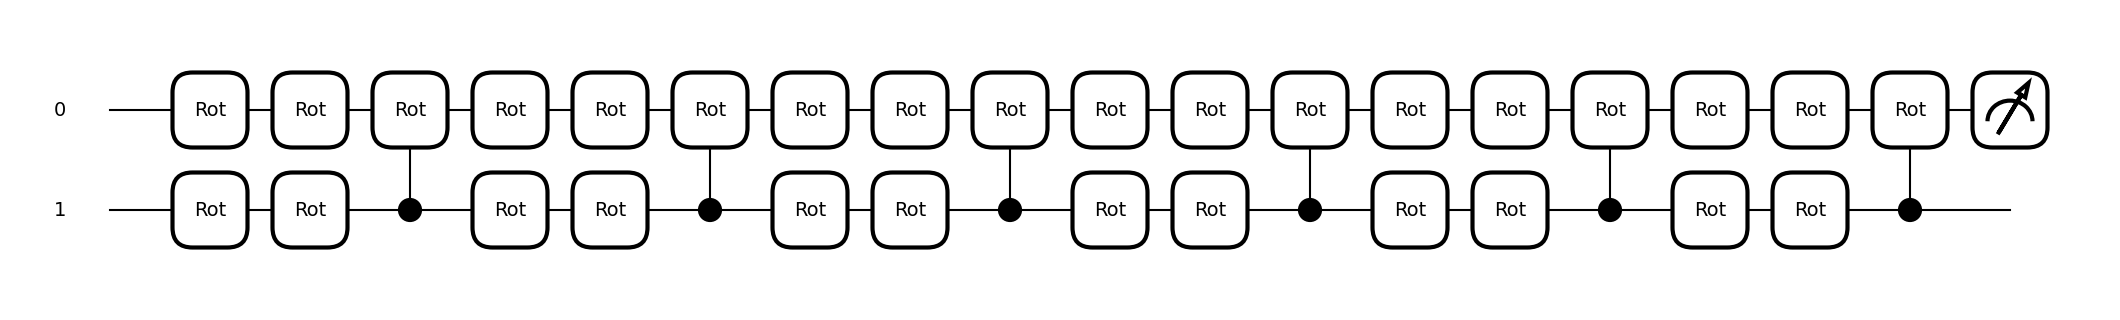

In [20]:
print(qml.draw_mpl(qnode_prueba_2q)(x_prueba, theta_prueba_2q, phi_prueba_2q))

**Pruebo el circuito con 3 qubit para ver dim.**

In [21]:
n_qubits_prueba = 3

qnode_prueba_3q = construir_qnode_clasificador(n_qubits=n_qubits_prueba, n_capas=N_CAPAS)
theta_prueba_3q = torch.randn(N_CAPAS, n_qubits_prueba, 3, dtype=torch.float32, device=DISPOSITIVO, requires_grad=True)
phi_prueba_3q = torch.zeros(N_CAPAS, n_qubits_prueba - 1, 3, dtype=torch.float32, device=DISPOSITIVO, requires_grad=True)
salida_prueba_3q = qnode_prueba_3q(x_prueba, theta_prueba_3q, phi_prueba_3q)

print("=== Prueba 3 qubits ===")
print("x_prueba:", x_prueba.shape)
print("theta:", theta_prueba_3q.shape)
print("phi:", phi_prueba_3q.shape)
print("Salida <Z0>:", salida_prueba_3q)

=== Prueba 3 qubits ===
x_prueba: torch.Size([3])
theta: torch.Size([6, 3, 3])
phi: torch.Size([6, 2, 3])
Salida <Z0>: tensor(0.0422, device='cuda:0', dtype=torch.float64, grad_fn=<ViewBackward0>)


(<Figure size 2700x400 with 1 Axes>, <Axes: >)


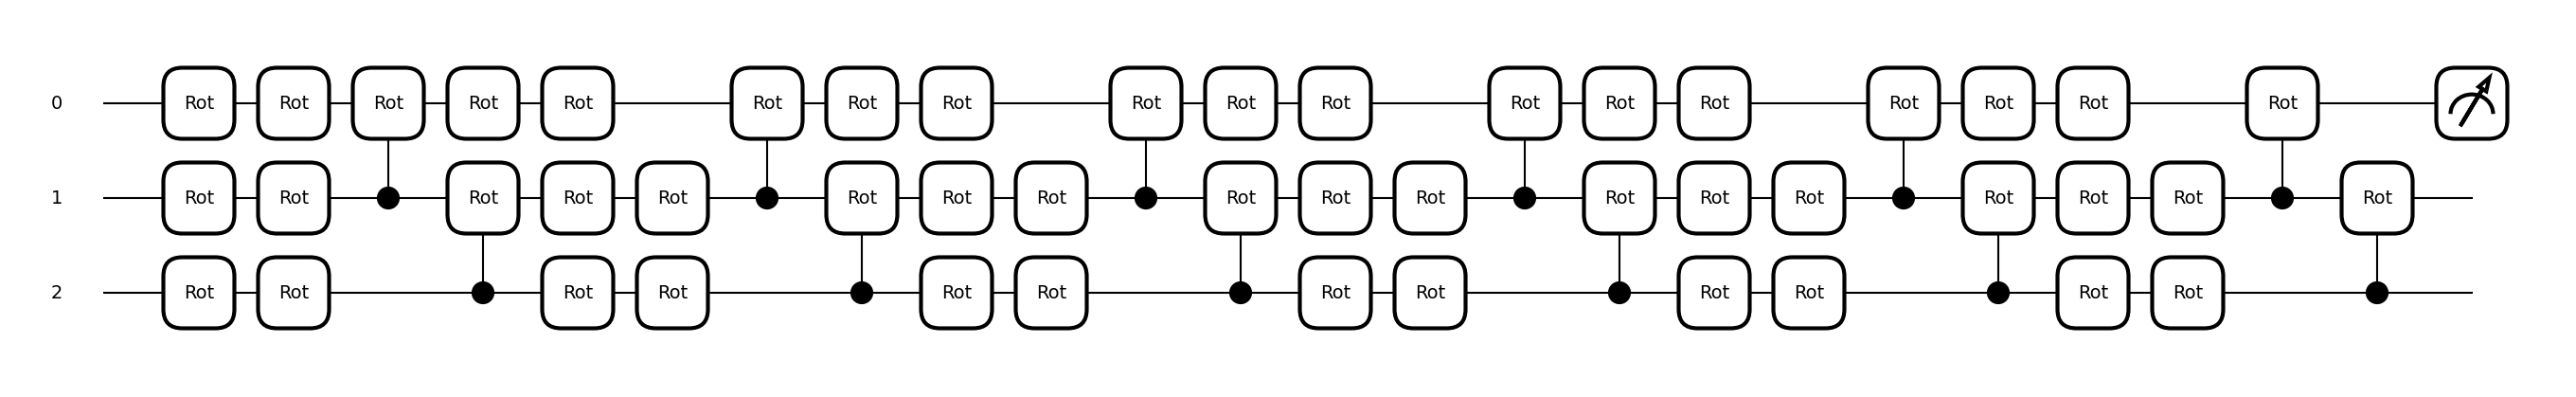

In [22]:
print(qml.draw_mpl(qnode_prueba_3q)(x_prueba, theta_prueba_3q, phi_prueba_3q))

# **3. Modelo en PyTorch de la QNNClassifier**

**Definir la clase QNNClassifier**

Los parámetros cuánticos son:

    theta → rotaciones locales qml.Rot
    phi   → rotaciones controladas qml.CRot

Los parámetros clásicos son:

    escala
    bias

In [23]:
class QNNClassifier(nn.Module):
    """
    Clasificador binario basado en una QNN de data re-uploading.
        theta: Parámetros entrenables de las rotaciones locales. // Forma: (n_capas, n_qubits, 3)
        phi: Parámetros entrenables de las compuertas controladas. // Forma: (n_capas, n_qubits - 1, 3)
        escala: Parámetro clásico entrenable para escalar <Z0>.
        bias: Sesgo clásico entrenable.
    Forward: x -> QNode -> <Z0> -> logit
    """
    def __init__(self, n_qubits, n_capas, inicializar_phi_cero=True):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_capas = n_capas

        # QNode asociado a este número de qubits.
        self.qnode = construir_qnode_clasificador(n_qubits=n_qubits, n_capas=n_capas)

        # Parámetros locales entrenables.
        self.theta = nn.Parameter(0.1 * torch.randn(n_capas, n_qubits, 3, dtype=torch.float32, device=DISPOSITIVO))

        # Para 1 qubit no existe phi físico.
        # Usamos dimensión dummy para mantener la misma firma.
        n_phi = max(n_qubits - 1, 1)

        if inicializar_phi_cero: 
            phi_inicial = torch.zeros(n_capas, n_phi, 3, dtype=torch.float32, device=DISPOSITIVO)
        else:
            phi_inicial = 0.1 * torch.randn(n_capas, n_phi, 3, dtype=torch.float32, device=DISPOSITIVO)

        self.phi = nn.Parameter(phi_inicial)

        # Capa clásica mínima para convertir <Z0> en logit.
        self.escala = nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DISPOSITIVO))

        self.bias = nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DISPOSITIVO))

**Definir el método forward**

Esta celda añade el forward a la clase. Como PennyLane evalúa un punto x a la vez, procesamos el batch con un ciclo. Tengo que pensar más a detalle para ver si en simulación puedo hacer algo similar a pasar muchos datos como la HQCNN.

    Evalúa un batch de datos.

    Parámetros x_batch: Tensor de forma (batch_size, 3).

    Regresa logits: Tensor de forma (batch_size,).

    Nota: Cada elemento del batch se pasa individualmente al QNode.


In [24]:
def forward_qnn_classifier(self, x_batch):

    salidas_z = []

    for x in x_batch:
        z = self.qnode(x, self.theta, self.phi)
        salidas_z.append(z)

    salidas_z = torch.stack(salidas_z)

    # Convertimos <Z0> en logit.
    logits = self.escala * salidas_z + self.bias

    return logits.float()

# Asociamos el método forward a la clase.
QNNClassifier.forward = forward_qnn_classifier

**Instancias de prueba:**

In [25]:
modelo_prueba_1q = QNNClassifier(n_qubits=1, n_capas=N_CAPAS).to(DISPOSITIVO)

x_batch_prueba, y_batch_prueba = next(iter(train_loader))

logits_prueba_1q = modelo_prueba_1q(x_batch_prueba)

print("=== Modelo 1Q ===")
print("x_batch:", x_batch_prueba.shape)
print("y_batch:", y_batch_prueba.shape)
print("logits:", logits_prueba_1q.shape)
print("Primeros logits:", logits_prueba_1q[:5])

=== Modelo 1Q ===
x_batch: torch.Size([32, 3])
y_batch: torch.Size([32])
logits: torch.Size([32])
Primeros logits: tensor([ 0.9010,  0.3273,  0.9576,  0.8957, -0.8623], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [26]:
modelo_prueba_2q = QNNClassifier(n_qubits=2, n_capas=N_CAPAS).to(DISPOSITIVO)

logits_prueba_2q = modelo_prueba_2q(x_batch_prueba)

print("=== Modelo 2Q ===")
print("x_batch:", x_batch_prueba.shape)
print("logits:", logits_prueba_2q.shape)
print("Primeros logits:", logits_prueba_2q[:5])

=== Modelo 2Q ===
x_batch: torch.Size([32, 3])
logits: torch.Size([32])
Primeros logits: tensor([ 0.7758,  0.2099,  0.9867,  0.9408, -0.9474], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [27]:
modelo_prueba_3q = QNNClassifier(n_qubits=3, n_capas=N_CAPAS).to(DISPOSITIVO)

logits_prueba_3q = modelo_prueba_3q(x_batch_prueba)

print("=== Modelo 3Q ===")
print("x_batch:", x_batch_prueba.shape)
print("logits:", logits_prueba_3q.shape)
print("Primeros logits:", logits_prueba_3q[:5])

=== Modelo 3Q ===
x_batch: torch.Size([32, 3])
logits: torch.Size([32])
Primeros logits: tensor([ 0.8930,  0.7853,  0.8961,  0.9986, -0.5960], device='cuda:0',
       grad_fn=<SliceBackward0>)


**Verificar parámetros entrenables:**

Imprime los parámetros entrenables de un modelo QNNClassifier.


In [28]:
def mostrar_parametros_modelo(modelo):
    total = 0
    for nombre, parametro in modelo.named_parameters():
        num_parametros = parametro.numel()
        total += num_parametros
        print(nombre, tuple(parametro.shape), "->", num_parametros)
    print("Total parámetros PyTorch:", total)

In [29]:
print("=== Modelo 1Q ===")
mostrar_parametros_modelo(modelo_prueba_1q)

print("=== Modelo 2Q ===")
mostrar_parametros_modelo(modelo_prueba_2q)

print("=== Modelo 3Q ===")
mostrar_parametros_modelo(modelo_prueba_3q)

=== Modelo 1Q ===
theta (6, 1, 3) -> 18
phi (6, 1, 3) -> 18
escala () -> 1
bias () -> 1
Total parámetros PyTorch: 38
=== Modelo 2Q ===
theta (6, 2, 3) -> 36
phi (6, 1, 3) -> 18
escala () -> 1
bias () -> 1
Total parámetros PyTorch: 56
=== Modelo 3Q ===
theta (6, 3, 3) -> 54
phi (6, 2, 3) -> 36
escala () -> 1
bias () -> 1
Total parámetros PyTorch: 92


**Definir función de pérdida**

Usare BCEWithLogitsLoss

In [30]:
criterio = nn.BCEWithLogitsLoss()

print("Función de pérdida:", criterio)

Función de pérdida: BCEWithLogitsLoss()


Probamos:

In [31]:
loss_prueba = criterio(logits_prueba_1q, y_batch_prueba)

print("Loss de prueba:", loss_prueba.item())
print("logits shape:", logits_prueba_1q.shape)
print("labels shape:", y_batch_prueba.shape)

Loss de prueba: 1.0207951068878174
logits shape: torch.Size([32])
labels shape: torch.Size([32])


**Función auxiliar para convertir logits en predicciones:**

    logit
    ↓ sigmoid
    probabilidad
    ↓ threshold 0.5
    clase 0/1

In [32]:
def logits_a_predicciones(logits):

    probabilidades = torch.sigmoid(logits)
    predicciones = (probabilidades >= 0.5).long()

    return predicciones

In [33]:
predicciones_prueba = logits_a_predicciones(logits_prueba_1q)

print("Predicciones:", predicciones_prueba[:10])
print("Etiquetas reales:", y_batch_prueba[:10].long())

Predicciones: tensor([1, 1, 1, 1, 0, 1, 1, 1, 1, 1], device='cuda:0')
Etiquetas reales: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


# **04. Funciones de entrenamiento y evaluación**

**Calcular accuracy desde logits:**

In [34]:
def calcular_accuracy_desde_logits(logits, y_real):
 
    predicciones = logits_a_predicciones(logits)
    y_real_entero = y_real.long()
    accuracy = (predicciones == y_real_entero).float().mean().item()

    return accuracy

**Entrenamiento de una época:**

In [35]:
def entrenar_una_epoca(modelo, data_loader, criterio, optimizador):

    modelo.train()

    loss_total = 0.0
    acc_total = 0.0
    n_batches = 0

    for x_batch, y_batch in data_loader:
        optimizador.zero_grad()
        logits = modelo(x_batch)
        loss = criterio(logits, y_batch)
        loss.backward()
        optimizador.step()
        acc = calcular_accuracy_desde_logits(logits.detach(), y_batch)
        loss_total += loss.item()
        acc_total += acc
        n_batches += 1

    loss_promedio = loss_total / n_batches
    acc_promedio = acc_total / n_batches

    return loss_promedio, acc_promedio

**Para evaluar modelo:**

In [36]:
def evaluar_modelo(modelo, data_loader, criterio):
    modelo.eval()

    loss_total = 0.0
    acc_total = 0.0
    n_batches = 0

    with torch.no_grad():

        for x_batch, y_batch in data_loader:
            logits = modelo(x_batch)
            loss = criterio(logits,y_batch)
            acc = calcular_accuracy_desde_logits(logits, y_batch)
            loss_total += loss.item()
            acc_total += acc
            n_batches += 1

    loss_promedio = loss_total / n_batches
    acc_promedio = acc_total / n_batches

    return loss_promedio, acc_promedio

**Entrenamiento completo:**

In [37]:
def entrenar_modelo(modelo, train_loader, val_loader, criterio, optimizador, epochs, nombre_modelo="modelo"):

    historial_modelo = {"loss_train": [], "acc_train": [], "loss_val": [], "acc_val": []}

    for epoca in range(1, epochs + 1):

        loss_train, acc_train = entrenar_una_epoca(modelo=modelo, data_loader=train_loader, criterio=criterio, optimizador=optimizador)
        loss_val, acc_val = evaluar_modelo(modelo=modelo, data_loader=val_loader, criterio=criterio)

        historial_modelo["loss_train"].append(loss_train)
        historial_modelo["acc_train"].append(acc_train)
        historial_modelo["loss_val"].append(loss_val)
        historial_modelo["acc_val"].append(acc_val)

        print(
            f"[{nombre_modelo}] "
            f"Época {epoca:03d}/{epochs} | "
            f"Loss train: {loss_train:.4f} | "
            f"Acc train: {acc_train:.4f} | "
            f"Loss val: {loss_val:.4f} | "
            f"Acc val: {acc_val:.4f}"
        )

    return historial_modelo

**Para graficar historial**

In [38]:
def graficar_historial(historial_modelo, titulo="Historial de entrenamiento"):

    epocas = range(1, len(historial_modelo["loss_train"]) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epocas, historial_modelo["loss_train"], label="Train")
    plt.plot(epocas, historial_modelo["loss_val"], label="Val")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.grid(True)
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epocas, historial_modelo["acc_train"], label="Train")
    plt.plot(epocas, historial_modelo["acc_val"], label="Val")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.suptitle(titulo)
    plt.show()

**Evaluación final en tes:t**

In [39]:
def evaluar_en_test(modelo, test_loader, criterio, nombre_modelo="modelo"):

    loss_test, acc_test = evaluar_modelo(modelo=modelo,data_loader=test_loader,criterio=criterio)
    metricas = {"loss_test": loss_test, "acc_test": acc_test}

    print(f"\nResultados en test: {nombre_modelo}")
    print("------------------------------")
    print("Loss test:", round(loss_test, 4))
    print("Acc test:", round(acc_test, 4))

    return metricas

**Predicciones**

In [40]:
def obtener_predicciones(modelo, data_loader):

    modelo.eval()

    lista_y = []
    lista_pred = []
    lista_prob = []

    with torch.no_grad():

        for x_batch, y_batch in data_loader:
            logits = modelo(x_batch)
            probabilidades = torch.sigmoid(logits)
            predicciones = logits_a_predicciones(logits)
            lista_y.append(y_batch.detach().cpu())
            lista_pred.append(predicciones.detach().cpu())
            lista_prob.append(probabilidades.detach().cpu())

    y_reales = torch.cat(lista_y).numpy()
    y_pred = torch.cat(lista_pred).numpy()
    probabilidades = torch.cat(lista_prob).numpy()

    return y_reales, y_pred, probabilidades

**Reporte de clasificación**

In [41]:
def reporte_clasificacion(modelo, data_loader, nombre_modelo="modelo"):

    y_reales, y_pred, _ = obtener_predicciones(modelo=modelo, data_loader=data_loader)

    print(f"\nReporte de clasificación: {nombre_modelo}")
    print("----------------------------------------")

    print("Matriz de confusión:")
    print(confusion_matrix(y_reales, y_pred))

    print("\nClassification report:")
    print(classification_report(y_reales, y_pred, target_names=["Exterior", "Interior"])
    )

# **5. Entrenamiento QNN 1 qubit**

**Crear modelo qnn 1q**

In [42]:
modelo_1q = QNNClassifier(
    n_qubits=1,
    n_capas=N_CAPAS,
    inicializar_phi_cero=True
).to(DISPOSITIVO)

print("modelo qnn 1q creado\n")
mostrar_parametros_modelo(modelo_1q)

modelo qnn 1q creado

theta (6, 1, 3) -> 18
phi (6, 1, 3) -> 18
escala () -> 1
bias () -> 1
Total parámetros PyTorch: 38


**Crear optimizador**

In [43]:
optimizador_1q = torch.optim.Adam(
    modelo_1q.parameters(),
    lr=LR_1Q
)

print("\noptimizador creado")
print(optimizador_1q)


optimizador creado
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.05
    maximize: False
    weight_decay: 0
)


**Evaluación inicial**

In [44]:
loss_train_ini_1q, acc_train_ini_1q = evaluar_modelo(modelo=modelo_1q, data_loader=train_loader, criterio=criterio)
loss_val_ini_1q, acc_val_ini_1q = evaluar_modelo(modelo=modelo_1q, data_loader=val_loader, criterio=criterio)

print("\nevaluación inicial")
print("------------------")
print("loss train:", round(loss_train_ini_1q, 4))
print("acc train :", round(acc_train_ini_1q, 4))
print("loss val  :", round(loss_val_ini_1q, 4))
print("acc val   :", round(acc_val_ini_1q, 4))


evaluación inicial
------------------
loss train: 0.9733
acc train : 0.2375
loss val  : 0.9592
acc val   : 0.25


**Entrenamiento**

In [45]:
historial_1q = entrenar_modelo(modelo=modelo_1q, train_loader=train_loader, val_loader=val_loader, criterio=criterio, optimizador=optimizador_1q, epochs=EPOCHS_1Q, nombre_modelo="QNN 1Q")

[QNN 1Q] Época 001/30 | Loss train: 0.6400 | Acc train: 0.6250 | Loss val: 0.4971 | Acc val: 0.7688
[QNN 1Q] Época 002/30 | Loss train: 0.4642 | Acc train: 0.7656 | Loss val: 0.3955 | Acc val: 0.7688
[QNN 1Q] Época 003/30 | Loss train: 0.3641 | Acc train: 0.8000 | Loss val: 0.2858 | Acc val: 0.8500
[QNN 1Q] Época 004/30 | Loss train: 0.2740 | Acc train: 0.8844 | Loss val: 0.2228 | Acc val: 0.9125
[QNN 1Q] Época 005/30 | Loss train: 0.2074 | Acc train: 0.9375 | Loss val: 0.1799 | Acc val: 0.9313
[QNN 1Q] Época 006/30 | Loss train: 0.1773 | Acc train: 0.9375 | Loss val: 0.1899 | Acc val: 0.9313
[QNN 1Q] Época 007/30 | Loss train: 0.1658 | Acc train: 0.9406 | Loss val: 0.1332 | Acc val: 0.9625
[QNN 1Q] Época 008/30 | Loss train: 0.1496 | Acc train: 0.9516 | Loss val: 0.1315 | Acc val: 0.9563
[QNN 1Q] Época 009/30 | Loss train: 0.1461 | Acc train: 0.9453 | Loss val: 0.1350 | Acc val: 0.9375
[QNN 1Q] Época 010/30 | Loss train: 0.1524 | Acc train: 0.9359 | Loss val: 0.1123 | Acc val: 0.9750


**Guardar historial**

In [46]:
historial["1q"] = historial_1q

**Graficar entrenamiento**

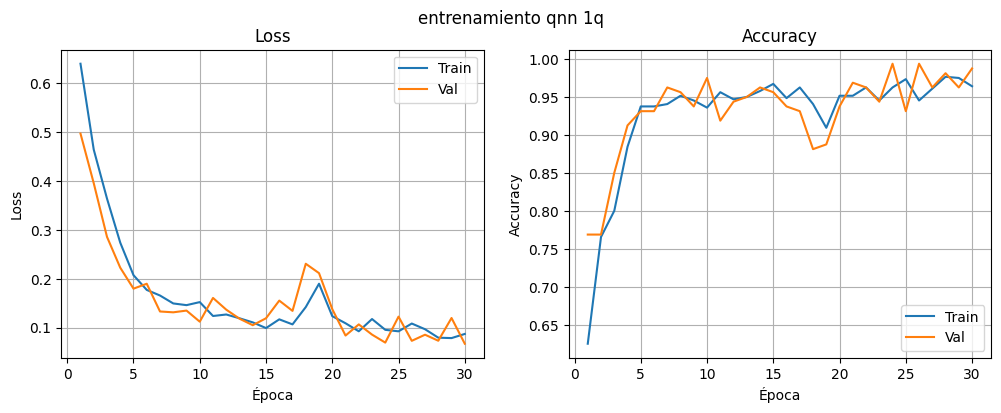

In [47]:
graficar_historial(historial_modelo=historial_1q, titulo="entrenamiento qnn 1q")

**Evaluación en test**

In [48]:
metricas_test_1q = evaluar_en_test(modelo=modelo_1q, test_loader=test_loader, criterio=criterio, nombre_modelo="QNN 1Q")


Resultados en test: QNN 1Q
------------------------------
Loss test: 0.0774
Acc test: 0.9598


**Guardar resultados**

In [49]:
resultados["1q"] = {"loss_train_final": historial_1q["loss_train"][-1], "acc_train_final": historial_1q["acc_train"][-1], "loss_val_final": historial_1q["loss_val"][-1], "acc_val_final": historial_1q["acc_val"][-1], "loss_test": metricas_test_1q["loss_test"], "acc_test": metricas_test_1q["acc_test"]}

print("\nresultados finales 1q")
print("---------------------")
print(resultados["1q"])


resultados finales 1q
---------------------
{'loss_train_final': 0.08723583878017963, 'acc_train_final': 0.9640625, 'loss_val_final': 0.06723435670137405, 'acc_val_final': 0.9875, 'loss_test': 0.07741966417857579, 'acc_test': 0.9598214285714286}


**Guardar parámetros entrenados**

In [50]:
parametros_entrenados["1q"] = {"theta": modelo_1q.theta.detach().clone(), "phi": modelo_1q.phi.detach().clone(), "escala": modelo_1q.escala.detach().clone(), "bias": modelo_1q.bias.detach().clone()}

print("\nparámetros guardados")
print("--------------------")
print("theta:", parametros_entrenados["1q"]["theta"].shape)
print("phi:", parametros_entrenados["1q"]["phi"].shape)


parámetros guardados
--------------------
theta: torch.Size([6, 1, 3])
phi: torch.Size([6, 1, 3])


**Reporte de clasificación**

In [51]:
reporte_clasificacion(modelo=modelo_1q, data_loader=test_loader, nombre_modelo="QNN 1Q")


Reporte de clasificación: QNN 1Q
----------------------------------------
Matriz de confusión:
[[151   2]
 [  4  43]]

Classification report:
              precision    recall  f1-score   support

    Exterior       0.97      0.99      0.98       153
    Interior       0.96      0.91      0.93        47

    accuracy                           0.97       200
   macro avg       0.96      0.95      0.96       200
weighted avg       0.97      0.97      0.97       200



**Inspección de predicciones**

In [52]:
y_reales_1q, y_pred_1q, probabilidades_1q = obtener_predicciones(modelo=modelo_1q, data_loader=test_loader)

print("\nprimeras 10 etiquetas reales")
print(y_reales_1q[:10].astype(int))

print("\nprimeras 10 predicciones")
print(y_pred_1q[:10])

print("\nprimeras 10 probabilidades")
print(np.round(probabilidades_1q[:10], 4))


primeras 10 etiquetas reales
[0 0 0 0 0 0 1 0 0 0]

primeras 10 predicciones
[0 0 0 0 0 0 1 0 0 0]

primeras 10 probabilidades
[3.300e-03 4.300e-03 6.000e-04 6.000e-04 1.900e-03 1.770e-02 9.948e-01
 5.000e-04 1.800e-03 1.300e-03]


**Frontera de decisión qnn 1q**

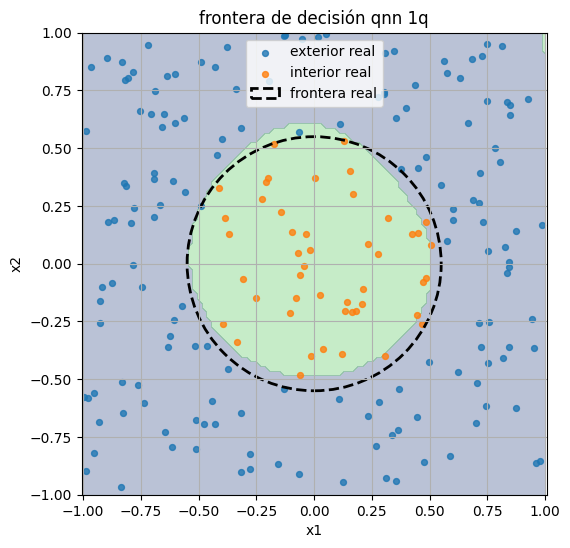

In [53]:
modelo_1q.eval()

resolucion = 100

x1_min, x1_max = -1.0, 1.0
x2_min, x2_max = -1.0, 1.0

grid_x1, grid_x2 = np.meshgrid(np.linspace(x1_min, x1_max, resolucion), np.linspace(x2_min, x2_max, resolucion))
grid_puntos = np.c_[grid_x1.ravel(), grid_x2.ravel()].astype(np.float32)
grid_puntos_rot = agregar_padding_rot(grid_puntos)
grid_tensor = torch.tensor(grid_puntos_rot,dtype=torch.float32,device=DISPOSITIVO)
predicciones_grid = []

with torch.no_grad():

    for i in range(0, grid_tensor.shape[0], BATCH_SIZE):
        batch_grid = grid_tensor[i:i + BATCH_SIZE]
        logits_grid = modelo_1q(batch_grid)
        pred_grid = logits_a_predicciones(logits_grid)
        predicciones_grid.append(pred_grid.detach().cpu())

predicciones_grid = torch.cat(predicciones_grid).numpy()
grid_pred = predicciones_grid.reshape(grid_x1.shape)

plt.figure(figsize=(6, 6))
plt.contourf(grid_x1, grid_x2, grid_pred, alpha=0.35, levels=[-0.5, 0.5, 1.5])
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], s=18, alpha=0.8, label="exterior real")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], s=18, alpha=0.8, label="interior real")
circulo_real = plt.Circle((0, 0), 0.55, fill=False, linestyle="--", linewidth=2, label="frontera real")
plt.gca().add_patch(circulo_real)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("frontera de decisión qnn 1q")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

**Resumen final**

In [54]:
print("\nresumen final qnn 1q")
print("--------------------")
print("accuracy test:", round(resultados["1q"]["acc_test"], 4))
print("loss test:", round(resultados["1q"]["loss_test"], 4))


resumen final qnn 1q
--------------------
accuracy test: 0.9598
loss test: 0.0774


# **6. Entrenamiento QNN 2 qubit**

**Crear modelo qnn 2q**

In [55]:
modelo_2q = QNNClassifier(n_qubits=2, n_capas=N_CAPAS, inicializar_phi_cero=True).to(DISPOSITIVO)

print("modelo qnn 2q creado\n")
mostrar_parametros_modelo(modelo_2q)

modelo qnn 2q creado

theta (6, 2, 3) -> 36
phi (6, 1, 3) -> 18
escala () -> 1
bias () -> 1
Total parámetros PyTorch: 56


**Inicialización iterativa desde 1q**

In [56]:
with torch.no_grad():

    # Copiamos los parámetros entrenados del modelo 1q
    # al primer qubit del modelo 2q.
    modelo_2q.theta[:, 0, :] = parametros_entrenados["1q"]["theta"][:, 0, :]

    # El segundo qubit conserva su inicialización aleatoria.
    # Los acoplamientos phi ya fueron inicializados en cero.
    modelo_2q.phi[:, 0, :] = 0.0

    # También copiamos escala y bias como punto de partida.
    modelo_2q.escala.copy_(parametros_entrenados["1q"]["escala"])
    modelo_2q.bias.copy_(parametros_entrenados["1q"]["bias"])

print("\ninicialización 1q -> 2q completada")
print("theta 2q:", modelo_2q.theta.shape)
print("phi 2q:", modelo_2q.phi.shape)


inicialización 1q -> 2q completada
theta 2q: torch.Size([6, 2, 3])
phi 2q: torch.Size([6, 1, 3])


**Verificación rápida de la inicialización**

In [57]:
diferencia_theta_0 = torch.max(torch.abs(modelo_2q.theta[:, 0, :] - parametros_entrenados["1q"]["theta"][:, 0, :])).item()
max_phi_2q = torch.max(torch.abs(modelo_2q.phi)).item()

print("\nverificación de inicialización")
print("-----------------------------")
print("diferencia theta qubit 0:", diferencia_theta_0)
print("máximo valor absoluto phi:", max_phi_2q)


verificación de inicialización
-----------------------------
diferencia theta qubit 0: 0.0
máximo valor absoluto phi: 0.0


**Optimizador 2q**

In [58]:
optimizador_2q = torch.optim.Adam(modelo_2q.parameters(), lr=LR_NQ)

print("\noptimizador 2q creado")
print(optimizador_2q)


optimizador 2q creado
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.005
    maximize: False
    weight_decay: 0
)


**Evaluación inicial 2q**

In [59]:
loss_train_ini_2q, acc_train_ini_2q = evaluar_modelo(modelo=modelo_2q, data_loader=train_loader, criterio=criterio)
loss_val_ini_2q, acc_val_ini_2q = evaluar_modelo(modelo=modelo_2q, data_loader=val_loader, criterio=criterio)

print("\nevaluación inicial 2q")
print("---------------------")
print("loss train:", round(loss_train_ini_2q, 4))
print("acc train :", round(acc_train_ini_2q, 4))
print("loss val  :", round(loss_val_ini_2q, 4))
print("acc val   :", round(acc_val_ini_2q, 4))


evaluación inicial 2q
---------------------
loss train: 0.0741
acc train : 0.9688
loss val  : 0.0672
acc val   : 0.9875


**Entrenamiento qnn 2q**

In [60]:
historial_2q = entrenar_modelo(modelo=modelo_2q, train_loader=train_loader, val_loader=val_loader, criterio=criterio, optimizador=optimizador_2q, epochs=EPOCHS_NQ, nombre_modelo="QNN 2Q")

[QNN 2Q] Época 001/30 | Loss train: 0.0681 | Acc train: 0.9859 | Loss val: 0.0654 | Acc val: 0.9812
[QNN 2Q] Época 002/30 | Loss train: 0.0654 | Acc train: 0.9891 | Loss val: 0.0610 | Acc val: 0.9812
[QNN 2Q] Época 003/30 | Loss train: 0.0623 | Acc train: 0.9906 | Loss val: 0.0643 | Acc val: 0.9875
[QNN 2Q] Época 004/30 | Loss train: 0.0651 | Acc train: 0.9828 | Loss val: 0.0564 | Acc val: 0.9875
[QNN 2Q] Época 005/30 | Loss train: 0.0634 | Acc train: 0.9828 | Loss val: 0.0572 | Acc val: 0.9875
[QNN 2Q] Época 006/30 | Loss train: 0.0601 | Acc train: 0.9906 | Loss val: 0.0546 | Acc val: 0.9875
[QNN 2Q] Época 007/30 | Loss train: 0.0566 | Acc train: 0.9891 | Loss val: 0.0546 | Acc val: 0.9875
[QNN 2Q] Época 008/30 | Loss train: 0.0564 | Acc train: 0.9875 | Loss val: 0.0528 | Acc val: 0.9875
[QNN 2Q] Época 009/30 | Loss train: 0.0547 | Acc train: 0.9906 | Loss val: 0.0535 | Acc val: 0.9812
[QNN 2Q] Época 010/30 | Loss train: 0.0535 | Acc train: 0.9891 | Loss val: 0.0533 | Acc val: 0.9875


**Guardar historial**

In [61]:
historial["2q"] = historial_2q

**Graficar entrenamiento**

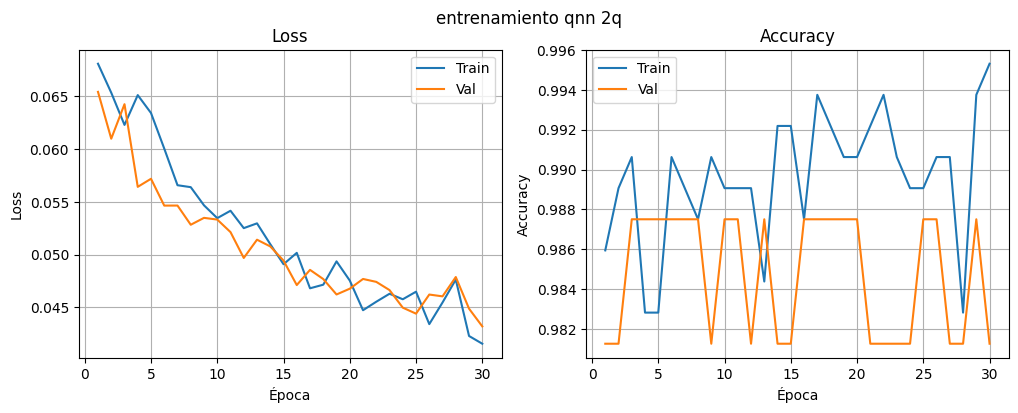

In [62]:
graficar_historial(historial_modelo=historial_2q, titulo="entrenamiento qnn 2q")

**Evaluación en test**

In [63]:
metricas_test_2q = evaluar_en_test(modelo=modelo_2q, test_loader=test_loader, criterio=criterio, nombre_modelo="QNN 2Q")


Resultados en test: QNN 2Q
------------------------------
Loss test: 0.0488
Acc test: 0.9777


**Guardar resultados**

In [64]:
resultados["2q"] = {"loss_train_final": historial_2q["loss_train"][-1], "acc_train_final": historial_2q["acc_train"][-1], "loss_val_final": historial_2q["loss_val"][-1], "acc_val_final": historial_2q["acc_val"][-1], "loss_test": metricas_test_2q["loss_test"], "acc_test": metricas_test_2q["acc_test"]}

print("\nresultados finales 2q")
print("---------------------")
print(resultados["2q"])


resultados finales 2q
---------------------
{'loss_train_final': 0.04153979064431042, 'acc_train_final': 0.9953125, 'loss_val_final': 0.043185726180672644, 'acc_val_final': 0.98125, 'loss_test': 0.04877994369183268, 'acc_test': 0.9776785714285714}


**Guardar parámetros entrenados**

In [65]:
parametros_entrenados["2q"] = {"theta": modelo_2q.theta.detach().clone(), "phi": modelo_2q.phi.detach().clone(), "escala": modelo_2q.escala.detach().clone(), "bias": modelo_2q.bias.detach().clone()}

print("\nparámetros guardados")
print("--------------------")
print("theta:", parametros_entrenados["2q"]["theta"].shape)
print("phi:", parametros_entrenados["2q"]["phi"].shape)


parámetros guardados
--------------------
theta: torch.Size([6, 2, 3])
phi: torch.Size([6, 1, 3])


**Reporte de clasificación**

In [66]:
reporte_clasificacion(modelo=modelo_2q, data_loader=test_loader, nombre_modelo="QNN 2Q")


Reporte de clasificación: QNN 2Q
----------------------------------------
Matriz de confusión:
[[153   0]
 [  2  45]]

Classification report:
              precision    recall  f1-score   support

    Exterior       0.99      1.00      0.99       153
    Interior       1.00      0.96      0.98        47

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.99       200
weighted avg       0.99      0.99      0.99       200



**Inspección de predicciones**

In [67]:
y_reales_2q, y_pred_2q, probabilidades_2q = obtener_predicciones(modelo=modelo_2q, data_loader=test_loader)

print("\nprimeras 10 etiquetas reales")
print(y_reales_2q[:10].astype(int))

print("\nprimeras 10 predicciones")
print(y_pred_2q[:10])

print("\nprimeras 10 probabilidades")
print(np.round(probabilidades_2q[:10], 4))


primeras 10 etiquetas reales
[0 0 0 0 0 0 1 0 0 0]

primeras 10 predicciones
[0 0 0 0 0 0 1 0 0 0]

primeras 10 probabilidades
[1.700e-03 1.000e-04 1.000e-04 0.000e+00 7.000e-04 1.930e-02 9.993e-01
 0.000e+00 2.000e-04 1.000e-04]


**Frontera de decisión qnn 2q**

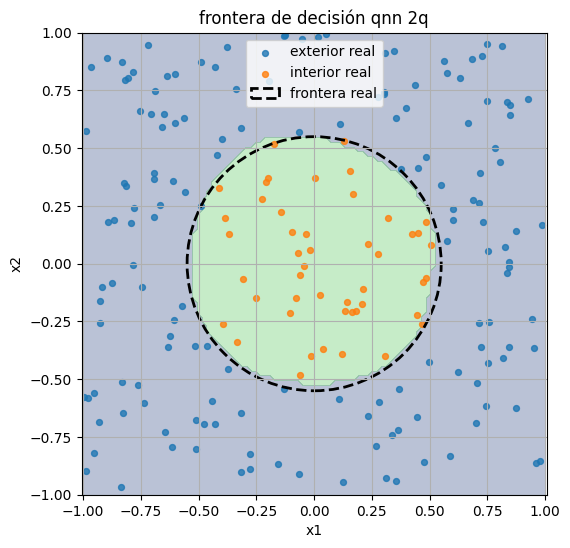

In [68]:
modelo_2q.eval()

resolucion = 100

x1_min, x1_max = -1.0, 1.0
x2_min, x2_max = -1.0, 1.0

grid_x1, grid_x2 = np.meshgrid(np.linspace(x1_min, x1_max, resolucion), np.linspace(x2_min, x2_max, resolucion))
grid_puntos = np.c_[grid_x1.ravel(), grid_x2.ravel()].astype(np.float32)
grid_puntos_rot = agregar_padding_rot(grid_puntos)
grid_tensor = torch.tensor(grid_puntos_rot, dtype=torch.float32, device=DISPOSITIVO)
predicciones_grid = []

with torch.no_grad():

    for i in range(0, grid_tensor.shape[0], BATCH_SIZE):
        batch_grid = grid_tensor[i:i + BATCH_SIZE]
        logits_grid = modelo_2q(batch_grid)
        pred_grid = logits_a_predicciones(logits_grid)
        predicciones_grid.append(pred_grid.detach().cpu())

predicciones_grid = torch.cat(predicciones_grid).numpy()
grid_pred = predicciones_grid.reshape(grid_x1.shape)

plt.figure(figsize=(6, 6))
plt.contourf(grid_x1, grid_x2, grid_pred,alpha=0.35, levels=[-0.5, 0.5, 1.5])
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], s=18,alpha=0.8, label="exterior real")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], s=18, alpha=0.8, label="interior real")
circulo_real = plt.Circle((0, 0), 0.55, fill=False, linestyle="--", linewidth=2, label="frontera real")
plt.gca().add_patch(circulo_real)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("frontera de decisión qnn 2q")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

**Resumen final**

In [69]:
print("\nresumen final qnn 2q")
print("--------------------")
print("accuracy test:", round(resultados["2q"]["acc_test"], 4))
print("loss test:", round(resultados["2q"]["loss_test"], 4))


resumen final qnn 2q
--------------------
accuracy test: 0.9777
loss test: 0.0488


# **7. Entrenamiento QNN 3 qubit**

**Crear modelo qnn 3q**

In [70]:
modelo_3q = QNNClassifier(n_qubits=3, n_capas=N_CAPAS, inicializar_phi_cero=True).to(DISPOSITIVO)

print("modelo qnn 3q creado\n")
mostrar_parametros_modelo(modelo_3q)

modelo qnn 3q creado

theta (6, 3, 3) -> 54
phi (6, 2, 3) -> 36
escala () -> 1
bias () -> 1
Total parámetros PyTorch: 92


**Inicialización iterativa desde 2q**

In [71]:
with torch.no_grad():

    # Copiamos los parámetros theta entrenados de los qubits 0 y 1
    # desde el modelo 2q hacia el modelo 3q.
    modelo_3q.theta[:, 0:2, :] = parametros_entrenados["2q"]["theta"][:, 0:2, :]

    # El tercer qubit conserva su inicialización aleatoria.
    # Copiamos el acoplamiento ya entrenado phi01.
    modelo_3q.phi[:, 0, :] = parametros_entrenados["2q"]["phi"][:, 0, :]

    # El nuevo acoplamiento phi12 se inicializa en cero.
    modelo_3q.phi[:, 1, :] = 0.0

    # Copiamos escala y bias como punto de partida.
    modelo_3q.escala.copy_(parametros_entrenados["2q"]["escala"])
    modelo_3q.bias.copy_(parametros_entrenados["2q"]["bias"])

print("\ninicialización 2q -> 3q completada")
print("theta 3q:", modelo_3q.theta.shape)
print("phi 3q:", modelo_3q.phi.shape)


inicialización 2q -> 3q completada
theta 3q: torch.Size([6, 3, 3])
phi 3q: torch.Size([6, 2, 3])


**Verificación rápida de la inicialización**

In [72]:
diferencia_theta_01 = torch.max(torch.abs(modelo_3q.theta[:, 0:2, :] - parametros_entrenados["2q"]["theta"][:, 0:2, :])).item()
diferencia_phi_01 = torch.max(torch.abs(modelo_3q.phi[:, 0, :] - parametros_entrenados["2q"]["phi"][:, 0, :])).item()
max_phi_12 = torch.max(torch.abs(modelo_3q.phi[:, 1, :])).item()

print("\nverificación de inicialización")
print("-----------------------------")
print("diferencia theta qubits 0-1:", diferencia_theta_01)
print("diferencia phi01:", diferencia_phi_01)
print("máximo valor absoluto phi12:", max_phi_12)


verificación de inicialización
-----------------------------
diferencia theta qubits 0-1: 0.0
diferencia phi01: 0.0
máximo valor absoluto phi12: 0.0


**Optimizador 3q**

In [73]:
optimizador_3q = torch.optim.Adam(modelo_3q.parameters(), lr=LR_NQ)

print("\noptimizador 3q creado")
print(optimizador_3q)


optimizador 3q creado
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.005
    maximize: False
    weight_decay: 0
)


**Evaluación inicial 3q**

In [74]:
loss_train_ini_3q, acc_train_ini_3q = evaluar_modelo(modelo=modelo_3q, data_loader=train_loader, criterio=criterio)
loss_val_ini_3q, acc_val_ini_3q = evaluar_modelo(modelo=modelo_3q, data_loader=val_loader, criterio=criterio)

print("\nevaluación inicial 3q")
print("---------------------")
print("loss train:", round(loss_train_ini_3q, 4))
print("acc train :", round(acc_train_ini_3q, 4))
print("loss val  :", round(loss_val_ini_3q, 4))
print("acc val   :", round(acc_val_ini_3q, 4))


evaluación inicial 3q
---------------------
loss train: 0.0418
acc train : 0.9875
loss val  : 0.0432
acc val   : 0.9812


**Entrenamiento qnn 3q**

In [75]:
historial_3q = entrenar_modelo(modelo=modelo_3q, train_loader=train_loader, val_loader=val_loader, criterio=criterio, optimizador=optimizador_3q, epochs=EPOCHS_NQ, nombre_modelo="QNN 3Q")

[QNN 3Q] Época 001/30 | Loss train: 0.0449 | Acc train: 0.9891 | Loss val: 0.0487 | Acc val: 0.9812
[QNN 3Q] Época 002/30 | Loss train: 0.0477 | Acc train: 0.9875 | Loss val: 0.0461 | Acc val: 0.9812
[QNN 3Q] Época 003/30 | Loss train: 0.0417 | Acc train: 0.9891 | Loss val: 0.0442 | Acc val: 0.9812
[QNN 3Q] Época 004/30 | Loss train: 0.0398 | Acc train: 0.9922 | Loss val: 0.0425 | Acc val: 0.9875
[QNN 3Q] Época 005/30 | Loss train: 0.0395 | Acc train: 0.9938 | Loss val: 0.0426 | Acc val: 0.9812
[QNN 3Q] Época 006/30 | Loss train: 0.0404 | Acc train: 0.9875 | Loss val: 0.0470 | Acc val: 0.9812
[QNN 3Q] Época 007/30 | Loss train: 0.0421 | Acc train: 0.9859 | Loss val: 0.0431 | Acc val: 0.9812
[QNN 3Q] Época 008/30 | Loss train: 0.0409 | Acc train: 0.9875 | Loss val: 0.0459 | Acc val: 0.9875
[QNN 3Q] Época 009/30 | Loss train: 0.0404 | Acc train: 0.9906 | Loss val: 0.0420 | Acc val: 0.9875
[QNN 3Q] Época 010/30 | Loss train: 0.0374 | Acc train: 0.9922 | Loss val: 0.0429 | Acc val: 0.9875


**Guardar historial**

In [76]:
historial["3q"] = historial_3q

**Graficar entrenamiento**

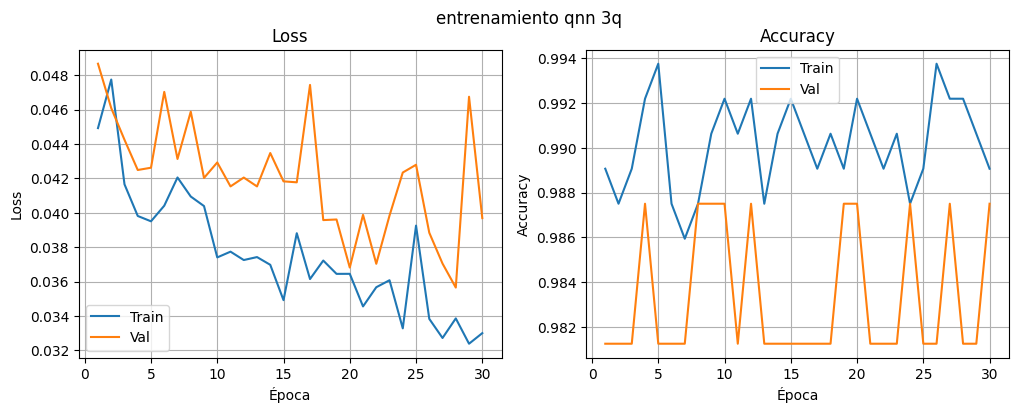

In [77]:
graficar_historial(historial_modelo=historial_3q, titulo="entrenamiento qnn 3q")

**Evaluación en test**

In [78]:
metricas_test_3q = evaluar_en_test(modelo=modelo_3q, test_loader=test_loader, criterio=criterio, nombre_modelo="QNN 3Q")


Resultados en test: QNN 3Q
------------------------------
Loss test: 0.0539
Acc test: 0.9732


**Guardar resultados**

In [79]:
resultados["3q"] = {"loss_train_final": historial_3q["loss_train"][-1], "acc_train_final": historial_3q["acc_train"][-1], "loss_val_final": historial_3q["loss_val"][-1], "acc_val_final": historial_3q["acc_val"][-1], "loss_test": metricas_test_3q["loss_test"], "acc_test": metricas_test_3q["acc_test"]}

print("\nresultados finales 3q")
print("---------------------")
print(resultados["3q"])


resultados finales 3q
---------------------
{'loss_train_final': 0.033002157625742254, 'acc_train_final': 0.9890625, 'loss_val_final': 0.03968917950987816, 'acc_val_final': 0.9875, 'loss_test': 0.05394344124943018, 'acc_test': 0.9732142857142857}


**Guardar parámetros entrenados**

In [80]:
parametros_entrenados["3q"] = {"theta": modelo_3q.theta.detach().clone(), "phi": modelo_3q.phi.detach().clone(), "escala": modelo_3q.escala.detach().clone(), "bias": modelo_3q.bias.detach().clone()}

print("\nparámetros guardados")
print("--------------------")
print("theta:", parametros_entrenados["3q"]["theta"].shape)
print("phi:", parametros_entrenados["3q"]["phi"].shape)


parámetros guardados
--------------------
theta: torch.Size([6, 3, 3])
phi: torch.Size([6, 2, 3])


**Reporte de clasificación**

In [81]:
reporte_clasificacion(modelo=modelo_3q, data_loader=test_loader, nombre_modelo="QNN 3Q")


Reporte de clasificación: QNN 3Q
----------------------------------------
Matriz de confusión:
[[152   1]
 [  2  45]]

Classification report:
              precision    recall  f1-score   support

    Exterior       0.99      0.99      0.99       153
    Interior       0.98      0.96      0.97        47

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



**Inspección de predicciones**

In [82]:
y_reales_3q, y_pred_3q, probabilidades_3q = obtener_predicciones(modelo=modelo_3q, data_loader=test_loader)

print("\nprimeras 10 etiquetas reales")
print(y_reales_3q[:10].astype(int))

print("\nprimeras 10 predicciones")
print(y_pred_3q[:10])

print("\nprimeras 10 probabilidades")
print(np.round(probabilidades_3q[:10], 4))


primeras 10 etiquetas reales
[0 0 0 0 0 0 1 0 0 0]

primeras 10 predicciones
[0 0 0 0 0 0 1 0 0 0]

primeras 10 probabilidades
[3.000e-04 0.000e+00 0.000e+00 0.000e+00 3.000e-04 4.900e-03 9.998e-01
 0.000e+00 1.000e-04 0.000e+00]


**Frontera de decisión qnn 3q**

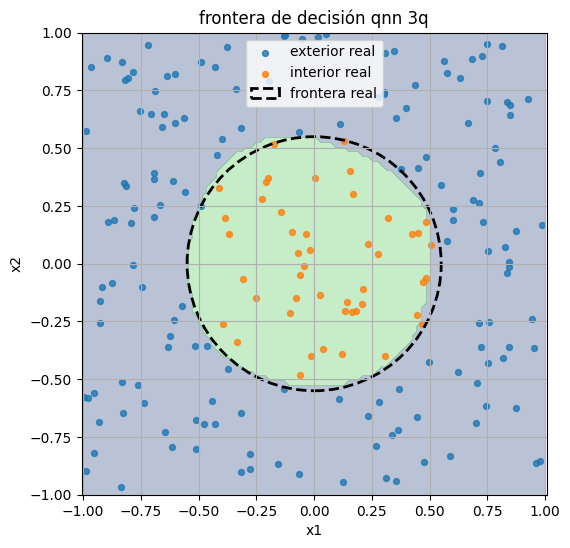

In [83]:
modelo_3q.eval()

resolucion = 100

x1_min, x1_max = -1.0, 1.0
x2_min, x2_max = -1.0, 1.0

grid_x1, grid_x2 = np.meshgrid(np.linspace(x1_min, x1_max, resolucion), np.linspace(x2_min, x2_max, resolucion))
grid_puntos = np.c_[grid_x1.ravel(), grid_x2.ravel()].astype(np.float32)
grid_puntos_rot = agregar_padding_rot(grid_puntos)
grid_tensor = torch.tensor(grid_puntos_rot, dtype=torch.float32, device=DISPOSITIVO)
predicciones_grid = []

with torch.no_grad():

    for i in range(0, grid_tensor.shape[0], BATCH_SIZE):
        batch_grid = grid_tensor[i:i + BATCH_SIZE]en
        logits_grid = modelo_3q(batch_grid)
        pred_grid = logits_a_predicciones(logits_grid)
        predicciones_grid.append(pred_grid.detach().cpu())

predicciones_grid = torch.cat(predicciones_grid).numpy()
grid_pred = predicciones_grid.reshape(grid_x1.shape)
plt.figure(figsize=(6, 6))
plt.contourf(grid_x1, grid_x2, grid_pred, alpha=0.35, levels=[-0.5, 0.5, 1.5])
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], s=18, alpha=0.8, label="exterior real")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], s=18, alpha=0.8, label="interior real")
circulo_real = plt.Circle((0, 0), 0.55, fill=False, linestyle="--", linewidth=2, label="frontera real")
plt.gca().add_patch(circulo_real)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("frontera de decisión qnn 3q")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

**Resumen final**

In [84]:
print("\nresumen final qnn 3q")
print("--------------------")
print("accuracy test:", round(resultados["3q"]["acc_test"], 4))
print("loss test:", round(resultados["3q"]["loss_test"], 4))


resumen final qnn 3q
--------------------
accuracy test: 0.9732
loss test: 0.0539


# **08. comparación de resultados qnn 1q, 2q y 3q**

**Agrupar modelos entrenados**

In [85]:
modelos_entrenados = {"1q": modelo_1q, "2q": modelo_2q, "3q": modelo_3q}

**Tabla comparativa**

In [86]:
filas_resultados = []

for clave_modelo, modelo_actual in modelos_entrenados.items():

    n_qubits = int(clave_modelo.replace("q", ""))
    parametros_theta = modelo_actual.theta.numel()
    parametros_phi = modelo_actual.phi.numel()
    parametros_clasicos = (modelo_actual.escala.numel() + modelo_actual.bias.numel())
    parametros_totales = (parametros_theta + parametros_phi + parametros_clasicos)
    fila = {"modelo": clave_modelo, "n_qubits": n_qubits, "parametros_theta": parametros_theta, "parametros_phi": parametros_phi, "parametros_clasicos": parametros_clasicos, "parametros_totales": parametros_totales, "loss_train": resultados[clave_modelo]["loss_train_final"], "acc_train": resultados[clave_modelo]["acc_train_final"], "loss_val": resultados[clave_modelo]["loss_val_final"], "acc_val": resultados[clave_modelo]["acc_val_final"], "loss_test": resultados[clave_modelo]["loss_test"], "acc_test": resultados[clave_modelo]["acc_test"]}
    filas_resultados.append(fila)

tabla_resultados = filas_resultados

print("tabla comparativa")
print("-----------------")

for fila in tabla_resultados:
    print(fila)

tabla comparativa
-----------------
{'modelo': '1q', 'n_qubits': 1, 'parametros_theta': 18, 'parametros_phi': 18, 'parametros_clasicos': 2, 'parametros_totales': 38, 'loss_train': 0.08723583878017963, 'acc_train': 0.9640625, 'loss_val': 0.06723435670137405, 'acc_val': 0.9875, 'loss_test': 0.07741966417857579, 'acc_test': 0.9598214285714286}
{'modelo': '2q', 'n_qubits': 2, 'parametros_theta': 36, 'parametros_phi': 18, 'parametros_clasicos': 2, 'parametros_totales': 56, 'loss_train': 0.04153979064431042, 'acc_train': 0.9953125, 'loss_val': 0.043185726180672644, 'acc_val': 0.98125, 'loss_test': 0.04877994369183268, 'acc_test': 0.9776785714285714}
{'modelo': '3q', 'n_qubits': 3, 'parametros_theta': 54, 'parametros_phi': 36, 'parametros_clasicos': 2, 'parametros_totales': 92, 'loss_train': 0.033002157625742254, 'acc_train': 0.9890625, 'loss_val': 0.03968917950987816, 'acc_val': 0.9875, 'loss_test': 0.05394344124943018, 'acc_test': 0.9732142857142857}


In [87]:
try:
    import pandas as pd
    df_resultados = pd.DataFrame(tabla_resultados)
    columnas_ordenadas = ["modelo","n_qubits","parametros_theta","parametros_phi","parametros_clasicos","parametros_totales","loss_train","acc_train","loss_val","acc_val","loss_test","acc_test"]
    df_resultados = df_resultados[columnas_ordenadas]
    display(df_resultados)

except Exception as error:
    print("no se pudo mostrar tabla con pandas")
    print("error:", error)

,modelo,n_qubits,parametros_theta,parametros_phi,parametros_clasicos,parametros_totales,loss_train,acc_train,loss_val,acc_val,loss_test,acc_test
0,1q,1,18,18,2,38,0.087236,0.964063,0.067234,0.98750,0.077420,0.959821
1,2q,2,36,18,2,56,0.041540,0.995313,0.043186,0.98125,0.048780,0.977679
2,3q,3,54,36,2,92,0.033002,0.989062,0.039689,0.98750,0.053943,0.973214


**Gráfico de accuracy por modelo**

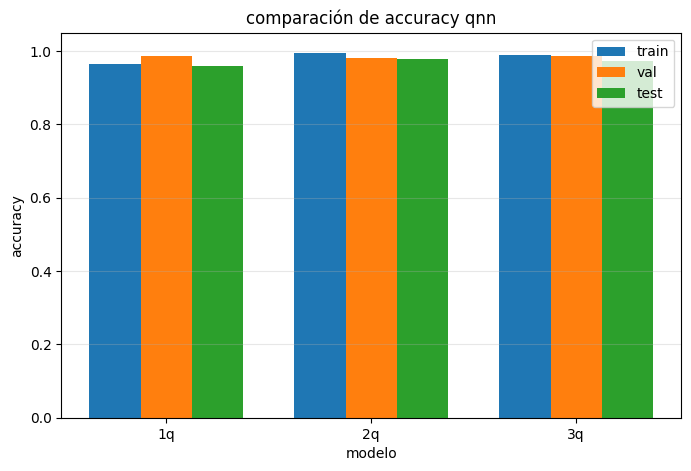

In [88]:
modelos = [fila["modelo"] for fila in tabla_resultados]

acc_train = [fila["acc_train"] for fila in tabla_resultados]
acc_val = [fila["acc_val"] for fila in tabla_resultados]
acc_test = [fila["acc_test"] for fila in tabla_resultados]

x_pos = np.arange(len(modelos))
ancho = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x_pos - ancho, acc_train, width=ancho, label="train")
plt.bar(x_pos, acc_val, width=ancho, label="val")
plt.bar(x_pos + ancho, acc_test, width=ancho, label="test")
plt.xticks(x_pos, modelos)
plt.ylim(0.0, 1.05)
plt.xlabel("modelo")
plt.ylabel("accuracy")
plt.title("comparación de accuracy qnn")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

**Gráfico de loss por modelo**

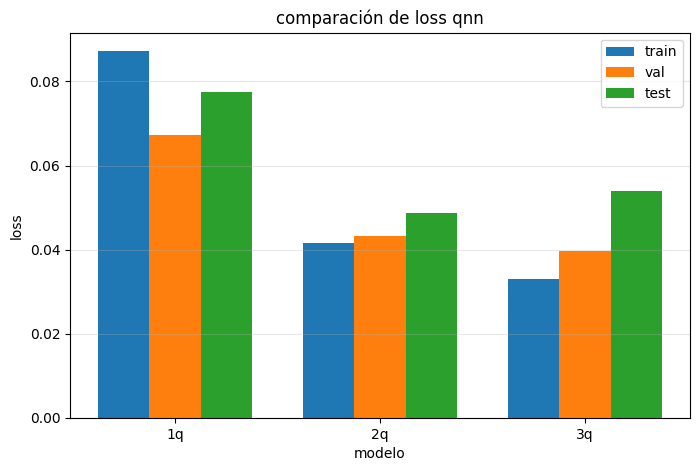

In [89]:
loss_train = [fila["loss_train"] for fila in tabla_resultados]
loss_val = [fila["loss_val"] for fila in tabla_resultados]
loss_test = [fila["loss_test"] for fila in tabla_resultados]

plt.figure(figsize=(8, 5))
plt.bar(x_pos - ancho, loss_train, width=ancho, label="train")
plt.bar(x_pos, loss_val, width=ancho, label="val")
plt.bar(x_pos + ancho, loss_test, width=ancho,label="test")
plt.xticks(x_pos, modelos)
plt.xlabel("modelo")
plt.ylabel("loss")
plt.title("comparación de loss qnn")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

**Gráfico de número de parámetros** (solo tomar en cuenta que por consturcción los de q1 son relamente 6, los 12 son 0)

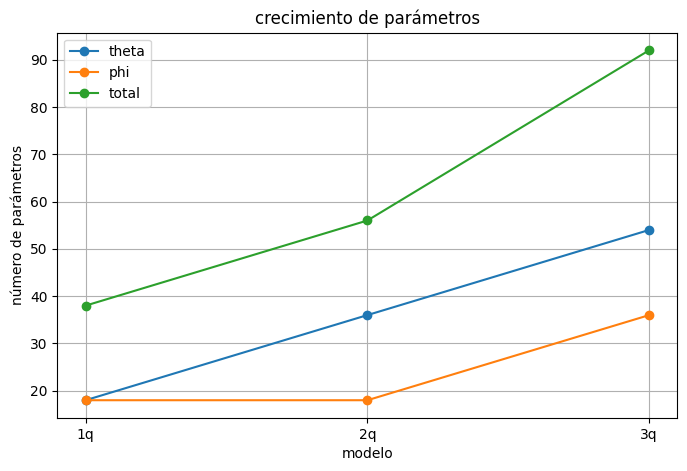

In [90]:
parametros_theta = [fila["parametros_theta"] for fila in tabla_resultados]
parametros_phi = [fila["parametros_phi"] for fila in tabla_resultados]
parametros_totales = [fila["parametros_totales"] for fila in tabla_resultados]

plt.figure(figsize=(8, 5))
plt.plot(modelos, parametros_theta, marker="o", label="theta")
plt.plot(modelos, parametros_phi, marker="o", label="phi")
plt.plot(modelos, parametros_totales, marker="o", label="total")
plt.xlabel("modelo")
plt.ylabel("número de parámetros")
plt.title("crecimiento de parámetros")
plt.grid(True)
plt.legend()
plt.show()

**Comparar curvas de loss train**

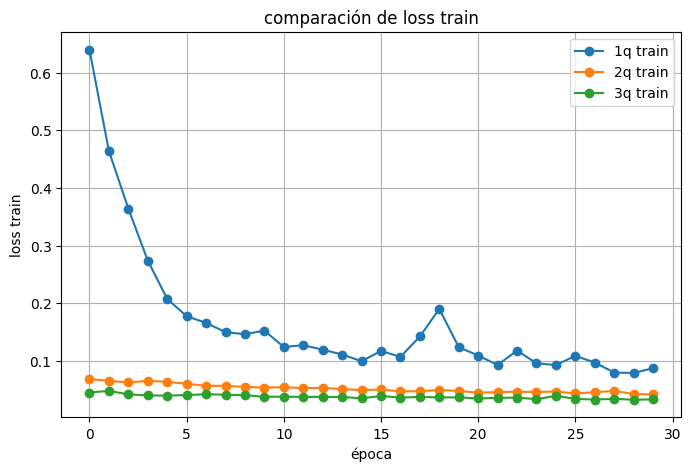

In [91]:
plt.figure(figsize=(8, 5))

for clave_modelo in ["1q", "2q", "3q"]:
    plt.plot(historial[clave_modelo]["loss_train"], marker="o", label=f"{clave_modelo} train")

plt.xlabel("época")
plt.ylabel("loss train")
plt.title("comparación de loss train")
plt.grid(True)
plt.legend()
plt.show()

**Comparar curvas de accuracy validation**

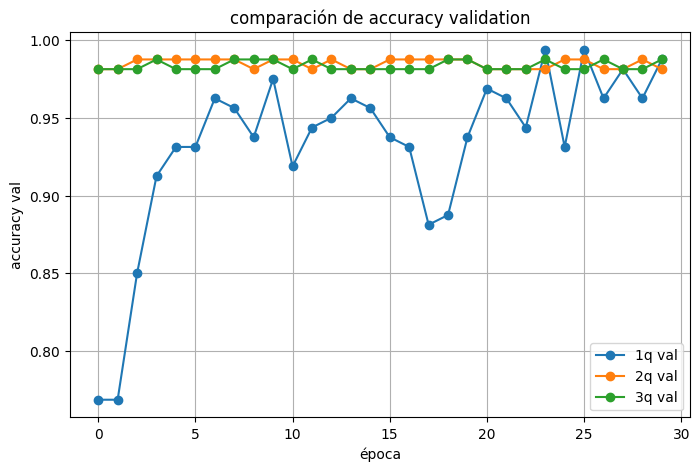

In [92]:
plt.figure(figsize=(8, 5))

for clave_modelo in ["1q", "2q", "3q"]:
    plt.plot(historial[clave_modelo]["acc_val"], marker="o", label=f"{clave_modelo} val")

plt.xlabel("época")
plt.ylabel("accuracy val")
plt.title("comparación de accuracy validation")
plt.grid(True)
plt.legend()
plt.show()

**Mejor modelo según accuracy test**

In [93]:
mejor_fila = max(tabla_resultados, key=lambda fila: fila["acc_test"])
mejor_modelo = mejor_fila["modelo"]

print("\nmejor modelo según accuracy test")
print("--------------------------------")
print("modelo:", mejor_modelo)
print("accuracy test:", round(mejor_fila["acc_test"], 4))
print("loss test:", round(mejor_fila["loss_test"], 4))
print("parámetros totales:", mejor_fila["parametros_totales"])


mejor modelo según accuracy test
--------------------------------
modelo: 2q
accuracy test: 0.9777
loss test: 0.0488
parámetros totales: 56


**Guardar resumen global en memoria**

In [94]:
resultados["comparativa"] = {"tabla": tabla_resultados,"mejor_modelo": mejor_modelo,"mejor_acc_test": mejor_fila["acc_test"],"mejor_loss_test": mejor_fila["loss_test"]}

print("\ncomparativa guardada en resultados['comparativa']")


comparativa guardada en resultados['comparativa']


---

Ya terminamos la Etapa 1: QNN classifier 1q → 2q → 3q.

Lo que sigue es Etapa 2: Neural Quantum Kernel.

La nueva estructura sería:

11. construir matrices kernel
    K_train = |<ψ(xi)|ψ(xj)>|²
    K_test  = |<ψ(xtest)|ψ(xtrain)>|²

12. entrenar SVM con kernel precomputado
    SVC(kernel="precomputed")

13. comparar QNN vs NQK
    accuracy QNN
    accuracy Kernel
    matriz de confusión
    tabla comparativa

14. frontera de decisión del kernel
    visualizar si mejora la frontera circular

15. cierre de etapa
    guardar en memoria parámetros y resultados finales